In [1]:
"""
# 09 — Arquitecturas Clásicas: LeNet, VGG y ResNet

"Módulo:" 05 — Deep Learning para Clasificación  
"Framework:" TensorFlow / Keras  
"Dataset:" MNIST y CIFAR-10
---
## ¿Qué vamos a aprender en este notebook?
1. La historia y evolución de las arquitecturas CNN más importantes
2. Implementar LeNet-5 — la primera CNN exitosa (1998)
3. Entender la filosofía de VGG — profundidad con kernels pequeños
4. Entender el problema del gradiente que ResNet resolvió
5. Implementar un bloque residual y ver por qué funciona
---
Estudiar estas arquitecturas no es solo historia los principios que introdujeron siguen siendo la base
de todas las CNNs modernas. Entenderlas te da criterio para diseñar y elegir arquitecturas en proyectos reales.

## 1. La evolución de las CNNs
1998  LeNet-5        → Primera CNN exitosa — dígitos escritos a mano
↓
2012  AlexNet        → Ganó ImageNet — inicio del boom del deep learning
↓
2014  VGGNet         → Profundidad con kernels 3×3 — simple y efectivo
↓
2015  ResNet         → Conexiones residuales — redes de 100+ capas
↓
2017  DenseNet       → Cada capa conectada a todas las anteriores
↓
2019  EfficientNet   → Escalar ancho, profundidad y resolución juntos

Cada arquitectura resolvió un problema específico que limitaba a las anteriores. Entender qué problema resolvió cada una
es más valioso que memorizar sus detalles técnicos.

| Arquitectura | Año | Problema que resolvió |
|---|---|---|
| "LeNet" | 1998 | Demostró que CNNs funcionan para imágenes |
| "AlexNet" | 2012 | Escaló a imágenes grandes con GPU |
| "VGG" | 2014 | Mostró que profundidad > kernels grandes |
| "ResNet" | 2015 | Resolvió el problema del gradiente desvaneciente |
"""

'\n# 09 — Arquitecturas Clásicas: LeNet, VGG y ResNet\n\n"Módulo:" 05 — Deep Learning para Clasificación  \n"Framework:" TensorFlow / Keras  \n"Dataset:" MNIST y CIFAR-10\n---\n## ¿Qué vamos a aprender en este notebook?\n1. La historia y evolución de las arquitecturas CNN más importantes\n2. Implementar LeNet-5 — la primera CNN exitosa (1998)\n3. Entender la filosofía de VGG — profundidad con kernels pequeños\n4. Entender el problema del gradiente que ResNet resolvió\n5. Implementar un bloque residual y ver por qué funciona\n---\nEstudiar estas arquitecturas no es solo historia los principios que introdujeron siguen siendo la base\nde todas las CNNs modernas. Entenderlas te da criterio para diseñar y elegir arquitecturas en proyectos reales.\n\n## 1. La evolución de las CNNs\n1998  LeNet-5        → Primera CNN exitosa — dígitos escritos a mano\n↓\n2012  AlexNet        → Ganó ImageNet — inicio del boom del deep learning\n↓\n2014  VGGNet         → Profundidad con kernels 3×3 — simple y e

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model

# Reproducibilidad
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {keras.__version__}")

TensorFlow version: 2.21.0
Keras version: 3.14.0


In [3]:
"""
## 2. LeNet-5 — La primera CNN exitosa (1998)

LeNet-5 fue desarrollada por Yann LeCun en 1998 para reconocer dígitos escritos a mano en cheques bancarios. Fue la primera CNN
en demostrar resultados prácticos en un problema real.
### Arquitectura original
Input (32×32×1)
↓
Conv2D(6, 5×5) → tanh       → output: 28×28×6
↓
AvgPooling(2×2)              → output: 14×14×6
↓
Conv2D(16, 5×5) → tanh      → output: 10×10×16
↓
AvgPooling(2×2)              → output: 5×5×16
↓
Flatten                      → output: 400
↓
Dense(120) → tanh
↓
Dense(84) → tanh
↓
Dense(10) → Softmax
### Diferencias con las CNNs modernas
- Usaba "tanh" en vez de ReLU — ReLU no existía aún
- Usaba "AvgPooling" en vez de MaxPooling
- Kernels de "5×5" en vez de 3×3
- Input de "32×32" — MNIST es 28×28, vamos a adaptarlo
Con solo ~60,000 parámetros LeNet era considerada enorme en 1998.
Las CNNs modernas tienen millones o miles de millones de parámetros.
"""

'\n## 2. LeNet-5 — La primera CNN exitosa (1998)\n\nLeNet-5 fue desarrollada por Yann LeCun en 1998 para reconocer dígitos escritos a mano en cheques bancarios. Fue la primera CNN\nen demostrar resultados prácticos en un problema real.\n### Arquitectura original\nInput (32×32×1)\n↓\nConv2D(6, 5×5) → tanh       → output: 28×28×6\n↓\nAvgPooling(2×2)              → output: 14×14×6\n↓\nConv2D(16, 5×5) → tanh      → output: 10×10×16\n↓\nAvgPooling(2×2)              → output: 5×5×16\n↓\nFlatten                      → output: 400\n↓\nDense(120) → tanh\n↓\nDense(84) → tanh\n↓\nDense(10) → Softmax\n### Diferencias con las CNNs modernas\n- Usaba "tanh" en vez de ReLU — ReLU no existía aún\n- Usaba "AvgPooling" en vez de MaxPooling\n- Kernels de "5×5" en vez de 3×3\n- Input de "32×32" — MNIST es 28×28, vamos a adaptarlo\nCon solo ~60,000 parámetros LeNet era considerada enorme en 1998.\nLas CNNs modernas tienen millones o miles de millones de parámetros.\n'

In [4]:
# Cargar MNIST para LeNet
(X_train_raw, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

# Normalizar
X_train_raw = X_train_raw.astype('float32') / 255.0
X_test      = X_test.astype('float32')      / 255.0

# LeNet espera input de 32×32 — redimensionar desde 28×28
X_train_raw = tf.image.resize(X_train_raw[..., np.newaxis], (32, 32)).numpy()
X_test      = tf.image.resize(X_test[..., np.newaxis],      (32, 32)).numpy()

# Separar validación
X_val   = X_train_raw[50000:]
X_train = X_train_raw[:50000]
y_val   = y_train[50000:]
y_train = y_train[:50000]

print(f"Train: {X_train.shape}")
print(f"Val:   {X_val.shape}")
print(f"Test:  {X_test.shape}")

Train: (50000, 32, 32, 1)
Val:   (10000, 32, 32, 1)
Test:  (10000, 32, 32, 1)


In [5]:
def build_lenet5(input_shape=(32, 32, 1), num_classes=10):
    """
    LeNet-5 adaptada para Keras moderno.
    Cambios respecto al original:
    - ReLU en vez de tanh
    - MaxPooling en vez de AvgPooling
    - Softmax en la salida
    """
    model = keras.Sequential([
        # Bloque 1
        layers.Conv2D(6, kernel_size=(5,5), activation='relu',
                      padding='valid', input_shape=input_shape),
        layers.MaxPooling2D(pool_size=(2,2)),

        # Bloque 2
        layers.Conv2D(16, kernel_size=(5,5), activation='relu',
                      padding='valid'),
        layers.MaxPooling2D(pool_size=(2,2)),

        # Clasificador
        layers.Flatten(),
        layers.Dense(120, activation='relu'),
        layers.Dense(84,  activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ], name='LeNet5')
    return model

lenet = build_lenet5()
lenet.summary()
print(f"\nParámetros totales: {lenet.count_params():,}")

C:\Users\Peter\ml_env\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "LeNet5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 28, 28, 6)           │             156 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 14, 14, 6)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 10, 10, 16)          │           2,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 5, 5, 16)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 400)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 120)                 │          48,120 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 84)                  │          10,164 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 10)                  │             850 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 61,706 (241.04 KB)

 Trainable params: 61,706 (241.04 KB)

 Non-trainable params: 0 (0.00 B)


Parámetros totales: 61,706


In [6]:
lenet.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Entrenando LeNet-5...")
history_lenet = lenet.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_val, y_val),
    verbose=0
)

val_acc  = max(history_lenet.history['val_accuracy'])
test_loss, test_acc = lenet.evaluate(X_test, y_test, verbose=0)
print(f"Mejor val_accuracy: {val_acc*100:.1f}%")
print(f"Test accuracy:      {test_acc*100:.1f}%")

Entrenando LeNet-5...
Mejor val_accuracy: 98.4%
Test accuracy:      98.7%


In [7]:

"""
## 3. VGGNet — Profundidad con kernels pequeños (2014)

VGG fue desarrollada por el Visual Geometry Group de Oxford en 2014.
Su contribución principal fue demostrar que "kernels pequeños (3×3) apilados son más efectivos que kernels grandes".

### La idea clave de VGG

Dos capas Conv2D con kernel 3×3 tienen el mismo "campo receptivo" que una capa con kernel 5×5, pero con menos parámetros y más
no-linealidades:
Una Conv 5×5:          Dos Conv 3×3 apiladas:
parámetros: 25         parámetros: 9 + 9 = 18
activaciones: 1        activaciones: 2

### Filosofía de diseño

- Kernels siempre de "3×3"
- Profundidad progresiva: 64 → 128 → 256 → 512 filtros
- Bloques de 2-3 capas conv seguidos de MaxPooling
- Muy simple y regular — fácil de entender y replicar

### Limitación
VGG16 tiene "138 millones de parámetros" — la mayoría en las capas densas finales. Muy pesada para entrenar desde cero.
"""

'\n## 3. VGGNet — Profundidad con kernels pequeños (2014)\n\nVGG fue desarrollada por el Visual Geometry Group de Oxford en 2014.\nSu contribución principal fue demostrar que "kernels pequeños (3×3) apilados son más efectivos que kernels grandes".\n\n### La idea clave de VGG\n\nDos capas Conv2D con kernel 3×3 tienen el mismo "campo receptivo" que una capa con kernel 5×5, pero con menos parámetros y más\nno-linealidades:\nUna Conv 5×5:          Dos Conv 3×3 apiladas:\nparámetros: 25         parámetros: 9 + 9 = 18\nactivaciones: 1        activaciones: 2\n\n### Filosofía de diseño\n\n- Kernels siempre de "3×3"\n- Profundidad progresiva: 64 → 128 → 256 → 512 filtros\n- Bloques de 2-3 capas conv seguidos de MaxPooling\n- Muy simple y regular — fácil de entender y replicar\n\n### Limitación\nVGG16 tiene "138 millones de parámetros" — la mayoría en las capas densas finales. Muy pesada para entrenar desde cero.\n'

In [8]:
def build_vgg_mini(input_shape=(32, 32, 1), num_classes=10):
    """
    VGG simplificada para MNIST.
    Misma filosofía que VGG16 pero adaptada a imágenes pequeñas:
    - Kernels siempre 3×3
    - Profundidad progresiva de filtros
    - Bloques conv + MaxPooling
    """
    model = keras.Sequential([
        # Bloque 1 — 32 filtros
        layers.Conv2D(32, (3,3), activation='relu', padding='same',
                      input_shape=input_shape),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),

        # Bloque 2 — 64 filtros
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),

        # Bloque 3 — 128 filtros
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),

        # Clasificador
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ], name='VGG_mini')
    return model

vgg = build_vgg_mini()
vgg.summary()
print(f"\nParámetros totales: {vgg.count_params():,}")

Model: "VGG_mini"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)                    │ (None, 32, 32, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 32, 32, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 16, 16, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 16, 16, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 16, 16, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 8, 8, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (None, 8, 8, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 8, 8, 128)           │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 4, 4, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 256)                 │         524,544 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 10)                  │           2,570 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 813,546 (3.10 MB)

 Trainable params: 813,546 (3.10 MB)

 Non-trainable params: 0 (0.00 B)


Parámetros totales: 813,546


In [9]:
vgg.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Entrenando VGG mini...")
history_vgg = vgg.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_val, y_val),
    verbose=0
)

val_acc  = max(history_vgg.history['val_accuracy'])
test_loss, test_acc = vgg.evaluate(X_test, y_test, verbose=0)
print(f"Mejor val_accuracy: {val_acc*100:.1f}%")
print(f"Test accuracy:      {test_acc*100:.1f}%")

Entrenando VGG mini...
Mejor val_accuracy: 99.3%
Test accuracy:      99.2%


In [10]:
"""
## 4. ResNet — Conexiones residuales (2015)

ResNet fue desarrollada por Microsoft Research en 2015 y ganó ImageNet con un error histórico. Su contribución fue resolver
el "problema del gradiente desvaneciente" en redes muy profundas.
### El problema
Al apilar muchas capas el gradiente se vuelve cada vez más pequeño a medida que viaja hacia atrás en la red — las capas tempranas
casi no aprenden nada.
Red de 50 capas sin residual:
Capa 50 → gradiente: 1.0
Capa 40 → gradiente: 0.1
Capa 30 → gradiente: 0.01
Capa 20 → gradiente: 0.001  ← casi no aprende
Capa 10 → gradiente: 0.0001 ← no aprende nada
### La solución — Skip connections
ResNet agrega "conexiones directas" que saltan una o más capas:
Input ──────────────────────────→ (+) → Output
↓                                ↑
Conv → BN → ReLU → Conv → BN ──────┘
(residual)
El gradiente ahora tiene un "camino directo" para viajar hacia atrás sin desvanecerse — las capas aprenden la "diferencia"
respecto a la identidad en vez de aprender desde cero.
"""

'\n## 4. ResNet — Conexiones residuales (2015)\n\nResNet fue desarrollada por Microsoft Research en 2015 y ganó ImageNet con un error histórico. Su contribución fue resolver\nel "problema del gradiente desvaneciente" en redes muy profundas.\n### El problema\nAl apilar muchas capas el gradiente se vuelve cada vez más pequeño a medida que viaja hacia atrás en la red — las capas tempranas\ncasi no aprenden nada.\nRed de 50 capas sin residual:\nCapa 50 → gradiente: 1.0\nCapa 40 → gradiente: 0.1\nCapa 30 → gradiente: 0.01\nCapa 20 → gradiente: 0.001  ← casi no aprende\nCapa 10 → gradiente: 0.0001 ← no aprende nada\n### La solución — Skip connections\nResNet agrega "conexiones directas" que saltan una o más capas:\nInput ──────────────────────────→ (+) → Output\n↓                                ↑\nConv → BN → ReLU → Conv → BN ──────┘\n(residual)\nEl gradiente ahora tiene un "camino directo" para viajar hacia atrás sin desvanecerse — las capas aprenden la "diferencia"\nrespecto a la identidad

In [11]:
def residual_block(x, filters, kernel_size=3, stride=1):
    """
    Bloque residual básico de ResNet.
    La conexión de skip suma la entrada directamente a la salida del bloque convolucional.
    """
    # Camino residual (skip connection)
    shortcut = x

    # Camino principal
    x = layers.Conv2D(filters, kernel_size, strides=stride,
                      padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    x = layers.Conv2D(filters, kernel_size, strides=1,
                      padding='same')(x)
    x = layers.BatchNormalization()(x)

    # Ajustar dimensiones del shortcut si es necesario
    if shortcut.shape[-1] != filters or stride != 1:
        shortcut = layers.Conv2D(filters, kernel_size=1,
                                 strides=stride, padding='same')(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    # Sumar shortcut + salida del bloque
    x = layers.Add()([x, shortcut])
    x = layers.Activation('relu')(x)

    return x

print("Bloque residual definido correctamente")

Bloque residual definido correctamente


In [12]:
def build_resnet_mini(input_shape=(32, 32, 1), num_classes=10):
    """
    ResNet simplificada para MNIST.
    Misma filosofía que ResNet pero adaptada a imágenes pequeñas:
    - Bloques residuales con skip connections
    - Batch Normalization en cada capa
    - Global Average Pooling en vez de Flatten + Dense grande
    """
    inputs = keras.Input(shape=input_shape)

    # Capa inicial
    x = layers.Conv2D(32, (3,3), padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    # Bloque residual 1 — 32 filtros
    x = residual_block(x, filters=32)

    # Bloque residual 2 — 64 filtros + stride 2 para reducir tamaño
    x = residual_block(x, filters=64, stride=2)

    # Bloque residual 3 — 128 filtros + stride 2
    x = residual_block(x, filters=128, stride=2)

    # Global Average Pooling — alternativa a Flatten + Dense grande
    x = layers.GlobalAveragePooling2D()(x)

    # Clasificador
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=inputs, outputs=outputs, name='ResNet_mini')
    return model

resnet = build_resnet_mini()
resnet.summary()
print(f"\nParámetros totales: {resnet.count_params():,}")

Model: "ResNet_mini"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)    │ (None, 32, 32, 1)         │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_8 (Conv2D)             │ (None, 32, 32, 32)        │             320 │ input_layer_2[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization           │ (None, 32, 32, 32)        │             128 │ conv2d_8[0][0]             │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation (Activation)       │ (None, 32, 32, 32)        │               0 │ batch_normalization[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_9 (Conv2D)             │ (None, 32, 32, 32)        │           9,248 │ activation[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_1         │ (None, 32, 32, 32)        │             128 │ conv2d_9[0][0]             │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_1 (Activation)     │ (None, 32, 32, 32)        │               0 │ batch_normalization_1[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_10 (Conv2D)            │ (None, 32, 32, 32)        │           9,248 │ activation_1[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_2         │ (None, 32, 32, 32)        │             128 │ conv2d_10[0][0]            │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ add (Add)                     │ (None, 32, 32, 32)        │               0 │ batch_normalization_2[0][… │
│                               │                           │                 │ activation[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_2 (Activation)     │ (None, 32, 32, 32)        │               0 │ add[0][0]                  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_11 (Conv2D)            │ (None, 16, 16, 64)        │          18,496 │ activation_2[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_3         │ (None, 16, 16, 64)        │             256 │ conv2d_11[0][0]            │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_3 (Activation)     │ (None, 16, 16, 64)        │               0 │ batch_normalization_3[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_12 (Conv2D)            │ (None, 16, 16, 64)        │          36,92

 Total params: 326,602 (1.25 MB)

 Trainable params: 325,258 (1.24 MB)

 Non-trainable params: 1,344 (5.25 KB)


Parámetros totales: 326,602


In [13]:
resnet.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Entrenando ResNet mini...")
history_resnet = resnet.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_val, y_val),
    verbose=0
)

val_acc = max(history_resnet.history['val_accuracy'])
test_loss, test_acc = resnet.evaluate(X_test, y_test, verbose=0)
print(f"Mejor val_accuracy: {val_acc*100:.1f}%")
print(f"Test accuracy:      {test_acc*100:.1f}%")

Entrenando ResNet mini...
Mejor val_accuracy: 98.9%
Test accuracy:      98.7%


In [14]:
"""
## 5. Comparación final de arquitecturas

Vamos a comparar las tres arquitecturas en términos de:
- Test accuracy
- Cantidad de parámetros
- Velocidad de convergencia
En deep learning más parámetros no siempre significa mejor resultado — la arquitectura y el diseño importan tanto como el tamaño del modelo.
"""

'\n## 5. Comparación final de arquitecturas\n\nVamos a comparar las tres arquitecturas en términos de:\n- Test accuracy\n- Cantidad de parámetros\n- Velocidad de convergencia\nEn deep learning más parámetros no siempre significa mejor resultado — la arquitectura y el diseño importan tanto como el tamaño del modelo.\n'

Arquitectura      Test Accuracy      Parámetros
LeNet-5                   98.7%          61,706
VGG mini                  99.2%         813,546
ResNet mini               98.7%         326,602


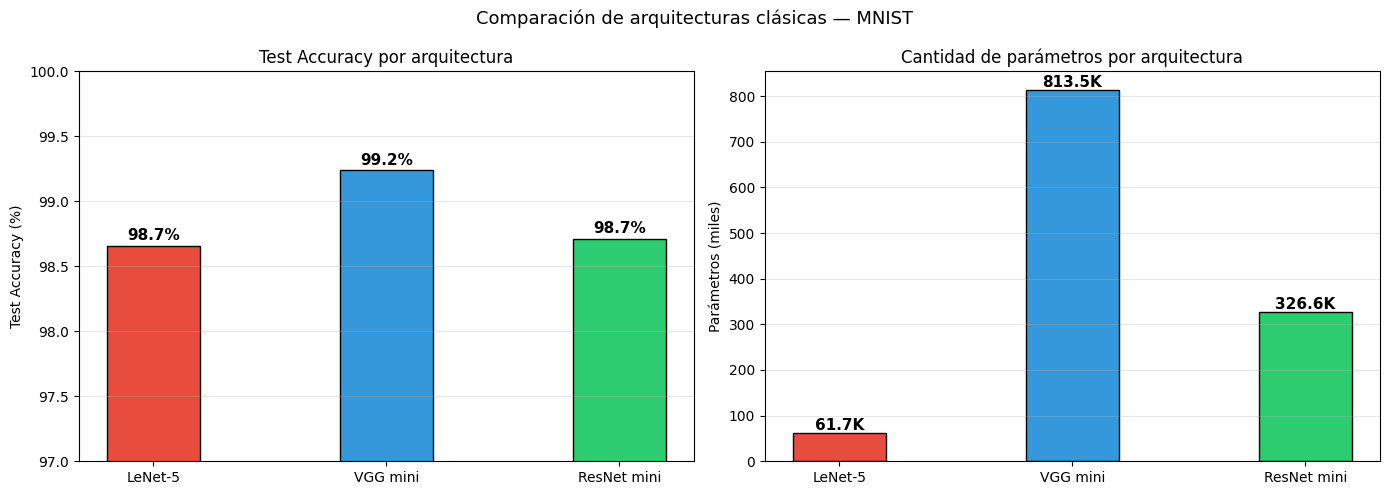

In [15]:
# Resultados de los tres modelos
resultados = {
    'LeNet-5':     {'test_acc': None, 'params': lenet.count_params()},
    'VGG mini':    {'test_acc': None, 'params': vgg.count_params()},
    'ResNet mini': {'test_acc': None, 'params': resnet.count_params()},
}

# Evaluar en test set
for nombre, model in [('LeNet-5', lenet), ('VGG mini', vgg), ('ResNet mini', resnet)]:
    _, acc = model.evaluate(X_test, y_test, verbose=0)
    resultados[nombre]['test_acc'] = acc

# Tabla comparativa
print("="*60)
print(f"{'Arquitectura':<15} {'Test Accuracy':>15} {'Parámetros':>15}")
print("="*60)
for nombre, res in resultados.items():
    print(f"{nombre:<15} {res['test_acc']*100:>14.1f}% {res['params']:>15,}")
print("="*60)

# Gráfico comparativo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Comparación de arquitecturas clásicas — MNIST', fontsize=13)

nombres   = list(resultados.keys())
accuracys = [resultados[n]['test_acc'] * 100 for n in nombres]
params    = [resultados[n]['params'] / 1000 for n in nombres]  # en miles
colores   = ['#e74c3c', '#3498db', '#2ecc71']

# Accuracy
bars = axes[0].bar(nombres, accuracys, color=colores, edgecolor='black', width=0.4)
axes[0].set_ylim(97, 100)
axes[0].set_ylabel('Test Accuracy (%)')
axes[0].set_title('Test Accuracy por arquitectura')
axes[0].grid(axis='y', alpha=0.3)
for bar, acc in zip(bars, accuracys):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{acc:.1f}%', ha='center', va='bottom',
                 fontsize=11, fontweight='bold')

# Parámetros
bars2 = axes[1].bar(nombres, params, color=colores, edgecolor='black', width=0.4)
axes[1].set_ylabel('Parámetros (miles)')
axes[1].set_title('Cantidad de parámetros por arquitectura')
axes[1].grid(axis='y', alpha=0.3)
for bar, p in zip(bars2, params):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{p:.1f}K', ha='center', va='bottom',
                 fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('../figures/09_comparacion_arquitecturas.png', dpi=120, bbox_inches='tight')
plt.show()

In [ ]:
"""
## 6. Curvas de convergencia comparadas

Más allá del accuracy final, las curvas nos muestran
cómo aprende cada arquitectura:
- "LeNet": converge rápido — arquitectura simple, pocas decisiones
- "VGG": converge progresivamente — más capas, más tiempo
- "ResNet": convergencia estable gracias a BatchNormalization
En problemas más complejos que MNIST verías diferencias mucho más dramáticas entre estas arquitecturas.
"""